In [1]:
from dotenv import load_dotenv
import os
load_dotenv()  # Load environment variables from .env file

True

In [2]:
import os
import requests

class NvidiaChat:
    def __init__(self, model="moonshotai/kimi-k2.5", temperature=0.9):
        self.model = model
        self.temperature = temperature
        self.api_key = os.getenv("NVIDIA_API_KEY")
        self.url = "https://integrate.api.nvidia.com/v1/chat/completions"

        if not self.api_key:
            raise ValueError("Set NVIDIA_API_KEY environment variable")

    def __call__(self, prompt: str) -> str:
        response = requests.post(
            self.url,
            headers={
                "Authorization": f"Bearer {self.api_key}",
                "Content-Type": "application/json",
            },
            json={
                "model": self.model,
                "messages": [{"role": "user", "content": prompt}],
                "temperature": self.temperature,
            },
        )
        return response.json()["choices"][0]["message"]["content"]

In [6]:
chat_llm = NvidiaChat(model="moonshotai/kimi-k2.5", temperature=0.9)

response = chat_llm("What is the capital of France?")
print(response)

 The capital of France is **Paris**.


In [3]:
from typing_extensions import TypedDict,Annotated
import operator

In [4]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, AnyMessage

In [5]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [47]:
def llm_call(state:GraphState)-> dict:
    """Call the LLM using conversation messages and append AI response"""
    prompt = state["messages"][-1].content
    response = chat_llm(prompt)
    return {"messages": [AIMessage(content=response)]}

In [35]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message"""
    last_mag = state["messages"][-1]
    text = last_mag.content
    token_count = len(text.split())
    summary  = f"total token number in the generated response is {token_count}"
    return {"message": [AIMessage(content=summary)]}

In [48]:
from langgraph.graph import StateGraph
builder = StateGraph(GraphState)

In [49]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [50]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [51]:
app = builder.compile()

In [52]:
app.get_graph() 

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [53]:
from IPython.display import Image, display

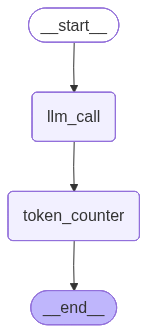

In [54]:
display(Image(app.get_graph().draw_mermaid_png()))

In [55]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of France?")]})
print(result)


{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}), AIMessage(content=' The capital of France is **Paris**.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


In [60]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [61]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [62]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [63]:
wiki_tool.run({"query":"what is  genai"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [6]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults()
result = tavily_tool.invoke("currect date and time")
print(result)

[{'title': 'The World Clock — Worldwide - Time and Date', 'url': 'https://www.timeanddate.com/worldclock/?sort=1..', 'content': '### Current Local Times Around the World\n\n\\ Adjusted for Daylight Saving Time  (6 places).\n\nWed = Wednesday, February 25, 2026  (106 places).  \nThu = Thursday, February 26, 2026  (37 places).\n\nUTC (GMT/Zulu)-time: Wednesday, February 25, 2026 at 20:14:25\n\nUTC is Coordinated Universal Time, GMT is Greenwich Mean Time.\n\nNeed some help?\n\n## More Information\n\n## Related Link\n\n## Related Time Zone Tools\n\nIllustration of a pink shield with a white heart.\n\n#### Love Our Site? Become a Supporter\n\nThe timeanddate logo\n\n© Time and Date AS 1995–2026\n\n#### Company\n\n#### Legal\n\n#### Services\n\n#### Sites\n\n#### Follow Us\n\n© Time and Date AS 1995–2026.\nPrivacy & Terms [...] timeanddate.com\n\n# The World Clock — Worldwide\n\nFind current time, weather, sun, moon, and much more...\n\n### My Cities (Personal World Clock) ... edit [...] | 

In [3]:
from langchain_community.tools import YouTubeSearchTool

In [7]:
youtube_tool = YouTubeSearchTool()

In [9]:
youtube_tool.name

'youtube_search'

In [10]:
youtube_tool.run("campusx")

"['https://www.youtube.com/watch?v=LGqaSsSLz68&pp=ygUHY2FtcHVzeA%3D%3D', 'https://www.youtube.com/watch?v=WzvURhaDZqI&pp=ygUHY2FtcHVzeA%3D%3D']"

In [11]:
def multiply(a: int, b: int) -> int:
    return a * b

In [12]:
multiply(3, 4)

12

converting function into tool

In [14]:
from langchain.tools import tool

In [15]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [16]:
multiply.invoke({"a": 3, "b": 4})

12

In [17]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of a word."""
    return len(word)

In [20]:
get_word_length.invoke("word hello")

10

In [21]:
@tool
def call_gamil_api(args):
    """Calls the Gmail API with the provided arguments."""
    pass

In [22]:
import yfinance as yf

In [26]:
@tool 
def get_stock_price(ticker:str)-> str:
    """this is a tool to get stock price using yfinance library"""
    try:
        stock = yf.Ticker(ticker)
        #get last 1 day historical data
        
        data  = stock.history(period="1d")
        if data.empty:
            return f"No data found for ticker {ticker} . Please check the symbol."
        
        lastest_close = data["Close"].iloc[-1]
        
        #Detect currency
        currency = stock.info.get("currency", "")
        symbol_map ={
            "INR":"₹",
            "USD":"$",
            "EUR":"€",
            "GBP":"£",
        }
        
        symbol = symbol_map.get(currency, "")
        curreny_text = currency if currency else ""
        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{lastest_close:.2f}."
        else:
            return f"the last closing price of {ticker.upper()} was {lastest_close:.2f} {curreny_text}."
    except Exception as e:
        return f"An error occurred while fetching stock price for {ticker}: {str(e)}"

In [28]:
get_stock_price.invoke("AAPL")

'the last closing price of AAPL was $264.72.'

In [31]:
get_stock_price.invoke("TSLA")

'the last closing price of TSLA was $403.32.'

In [32]:
get_stock_price.invoke("HDFCBANK.NS")

'the last closing price of HDFCBANK.NS was ₹879.40.'